## Theory

Given a state $ |\psi\rangle$ the energy is: 
$$ E[|\psi\rangle] = \frac{\langle\psi|H|\psi\rangle}{\langle\psi|\psi\rangle}$$


Let 
$$
\begin{split} 
|v_0\rangle &= \frac{|\psi\rangle}{\sqrt{\langle\psi|\psi\rangle}} \\
|\tilde v_1\rangle &= H|v_0\rangle-|v_0\rangle\langle v_0|H|v_0\rangle = (I-|v_0\rangle\langle v_0|)H|v_0\rangle\\
|v_1\rangle &= \frac{|\tilde v_1\rangle}{\sqrt{\langle \tilde v_1|\tilde v_1\rangle}}\\
\end{split}
$$

Trial state: $c_0 |v_0\rangle + c_1 |v_1\rangle$

$$
\begin{split}
c_0 H|v_0\rangle + c_1 H|v_1\rangle &= Ec_0 |v_0\rangle + Ec_1 |v_1\rangle \\
\begin{pmatrix}
\langle v_0|H|v_0\rangle & \langle v_0|H|v_1\rangle\\ 
\langle v_1|H|v_0\rangle & \langle v_1|H|v_1\rangle\\
\end{pmatrix}
\begin{pmatrix}
c_0 \\ c_1\\
\end{pmatrix}
&= 
E
\begin{pmatrix}
c_0 \\ c_1\\
\end{pmatrix}
\end{split}
$$
Let 

$$
H = \begin{pmatrix}
e_0 & \gamma \\
\gamma^* & e_1 \\
\end{pmatrix}
$$

$$ (e_0-\lambda)(e_1-\lambda) -|\gamma|^2=0$$
$$ \lambda^2 -\lambda(e_0+e_1) + e_0e_1 -|\gamma|^2=0$$


$$ \lambda = \frac{e_0+e_1\pm \sqrt{(e_0-e_1)^2+4|\gamma|^2}}{2}$$

Let $$ z = \sqrt{(e_0-e_1)^2+4|\gamma|^2}$$
$$ \lambda = \frac{e_0+e_1\pm z}{2}$$


$$e_0 c_0 + \gamma c_1 = \frac{e_0+e_1\pm z}{2}c_0$$

$$c_1 = \frac{-e_0+e_1\pm z}{2\gamma}c_0$$

In [1]:
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

In [2]:
n_sites = 10
hopping = 1.0

hamiltonian = np.zeros((n_sites, n_sites))
for i in range(n_sites):
    hamiltonian[i, (i + 1) % n_sites] = -hopping
    hamiltonian[i, (i - 1) % n_sites] = -hopping

hamiltonian

array([[ 0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.],
       [-1.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0., -1.,  0., -1.,  0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0., -1.,  0., -1.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  0., -1.,  0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  0., -1.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  0., -1.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  0., -1.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0., -1.],
       [-1.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  0.]])

In [3]:
ks = 2 * np.pi * np.arange(1, n_sites + 1) / n_sites
energies = -2 * hopping * np.cos(ks)

for k, e in zip(ks, energies):
    print(k, e)

e_min = energies.min()
k_min = ks[np.argmin(energies)]
psi_min = np.exp(1j * np.arange(1, 1 + n_sites) * k_min) / np.sqrt(n_sites)
psi_min = psi_min[:, None]

print(k_min, e_min)
print(psi_min)

0.6283185307179586 -1.618033988749895
1.2566370614359172 -0.6180339887498949
1.8849555921538759 0.6180339887498947
2.5132741228718345 1.6180339887498947
3.141592653589793 2.0
3.7699111843077517 1.618033988749895
4.39822971502571 0.6180339887498951
5.026548245743669 -0.6180339887498945
5.654866776461628 -1.6180339887498947
6.283185307179586 -2.0
6.283185307179586 -2.0
[[0.31622777-7.74534643e-17j]
 [0.31622777-1.54906929e-16j]
 [0.31622777-2.32360393e-16j]
 [0.31622777-3.09813857e-16j]
 [0.31622777-3.87267321e-16j]
 [0.31622777-4.64720786e-16j]
 [0.31622777-5.42174250e-16j]
 [0.31622777-6.19627714e-16j]
 [0.31622777-6.97081179e-16j]
 [0.31622777-7.74534643e-16j]]


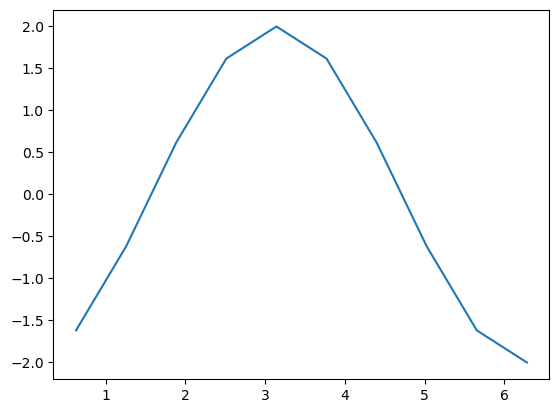

In [11]:
plt.plot(ks, energies)
plt.show()

In [5]:
# check analytic result
(hamiltonian - e_min * np.eye(n_sites)) @ psi_min

array([[0.+7.74534643e-16j],
       [0.+0.00000000e+00j],
       [0.+0.00000000e+00j],
       [0.+0.00000000e+00j],
       [0.+0.00000000e+00j],
       [0.+0.00000000e+00j],
       [0.+0.00000000e+00j],
       [0.+9.86076132e-32j],
       [0.-9.86076132e-32j],
       [0.-7.74534643e-16j]])

In [6]:
def expectation(state, operator):
    return (np.conj(state.T) @ (operator @ state)).item()


def infidelity(state, target):
    overlap = (np.conj(state.T) @ target).item()
    return 1.0 - np.abs(overlap) ** 2

In [7]:
@dataclass
class IterationResult:
    iteration: int
    energy: float
    infidelity: float

In [12]:
results = []
n_iter = 20

v0 = np.random.rand(n_sites) + 1j * np.random.rand(n_sites)
v0 = v0[:, None]
v0 /= np.linalg.norm(v0)

e0 = expectation(v0, hamiltonian).real
results.append(IterationResult(0, e0, infidelity(v0, psi_min)))
print(results[-1])

for i in range(n_iter):
    v1 = hamiltonian @ v0 - e0 * v0
    v1 /= np.linalg.norm(v1)
    e1 = expectation(v1, hamiltonian).real

    gamma = (np.conj(v0.T) @ (hamiltonian @ v1)).item()

    z = np.sqrt((e0 - e1) ** 2 + 4 * np.abs(gamma) ** 2)
    # lambda0 = (e0+e1 +z) * 0.5
    # lambda1 = (e0+e1 -z) * 0.5

    vec = np.array([1.0, (-e0 + e1 - z) / (2 * gamma)])
    vec /= np.linalg.norm(vec)
    v0 = vec[0] * v0 + vec[1] * v1
    v0 /= np.linalg.norm(v0)

    e0 = expectation(v0, hamiltonian).real
    results.append(IterationResult(i + 1, e0, infidelity(v0, psi_min)))
    print(results[-1])

IterationResult(iteration=0, energy=-1.182049339048468, infidelity=0.3521643226733373)
IterationResult(iteration=1, energy=-1.8917442786459926, infidelity=0.1004168254166048)
IterationResult(iteration=2, energy=-1.9679320411579313, infidelity=0.04675548379608363)
IterationResult(iteration=3, energy=-1.985359192315186, infidelity=0.029418788261361795)
IterationResult(iteration=4, energy=-1.99145673279661, infidelity=0.01948080580708167)
IterationResult(iteration=5, energy=-1.994396397109881, infidelity=0.013456766249477115)
IterationResult(iteration=6, energy=-1.9962084416119417, infidelity=0.009063322555577846)
IterationResult(iteration=7, energy=-1.9974163415290773, infidelity=0.006270226721577066)
IterationResult(iteration=8, energy=-1.9982378962692362, infidelity=0.004220062095372956)
IterationResult(iteration=9, energy=-1.9987983582043092, infidelity=0.0029171454268829278)
IterationResult(iteration=10, energy=-1.9991807411500324, infidelity=0.001962031397159114)
IterationResult(ite

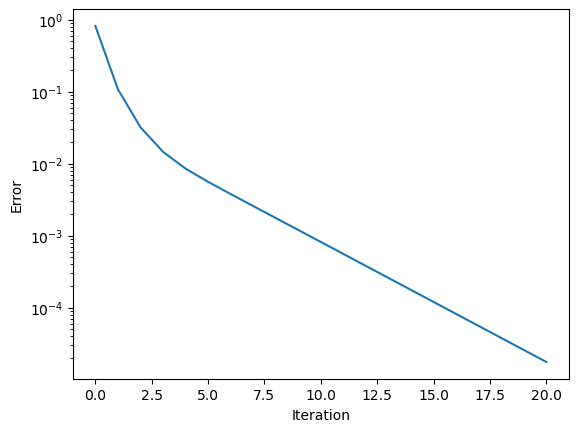

In [13]:
plt.plot([res.energy - e_min for res in results])
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.yscale("log")
plt.show()

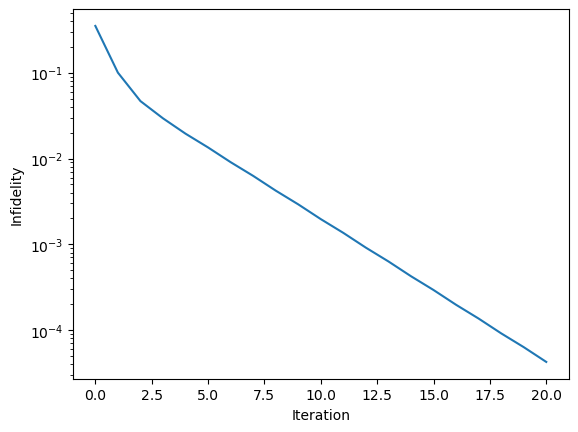

In [14]:
plt.plot([res.infidelity for res in results])
plt.xlabel("Iteration")
plt.ylabel("Infidelity")
plt.yscale("log")
plt.show()